# 07 — Hypothesis Testing

## H1: Predictors of MWI
## H2: Do training groups differ in MWI?
### Step 1: Bivariate Screening

Goal: identify which variables are worth including in the regression models via Spearman correlation (continuous) and Mann-Whitney U / Kruskal-Wallis (categorical).

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

DATA_PATH = '../data/processed/combined_data.csv'

In [100]:
df_all = pd.read_csv(DATA_PATH)
df = df_all[df_all['mwi'].notna()].copy()
df['mwi'] = pd.to_numeric(df['mwi'])

## 1. Continuous predictors

Spearman correlation is used throughout — it is non-parametric and more robust to small n and non-normal distributions than Pearson.

In [89]:
CONT_PREDICTORS = [
    ('bmi',               'BMI'),
    ('sleep_quality',     'Sleep Quality'),
    ('physical_recovery', 'Physical Recovery'),
    ('mental_recovery',   'Mental Recovery'),
    ('stress_score',      'Stress Score'),
    ('sitting_time',      'Sitting Time'),
    ('sedentary_score',   'Sedentary Score'),
    
]

rows = []
for col, label in CONT_PREDICTORS:
    x = pd.to_numeric(df[col], errors='coerce').dropna()
    y = df.loc[x.index, 'mwi']
    r, p = stats.spearmanr(x, y)
    rows.append({'Variable': label, 'n': len(x), 'Spearman ρ': round(r, 3), 'p-value': round(p, 3)})

cont_results = pd.DataFrame(rows).sort_values('Spearman ρ', key=abs, ascending=False)
print('Spearman correlations with MWI (sorted by |ρ|):')
cont_results

Spearman correlations with MWI (sorted by |ρ|):


,Variable,n,Spearman ρ,p-value
5,Sitting Time,25,0.430,0.032
3,Mental Recovery,25,0.241,0.246
1,Sleep Quality,25,-0.196,0.349
6,Sedentary Score,25,0.134,0.524
2,Physical Recovery,25,-0.126,0.548
4,Stress Score,25,0.053,0.802
0,BMI,25,-0.040,0.848


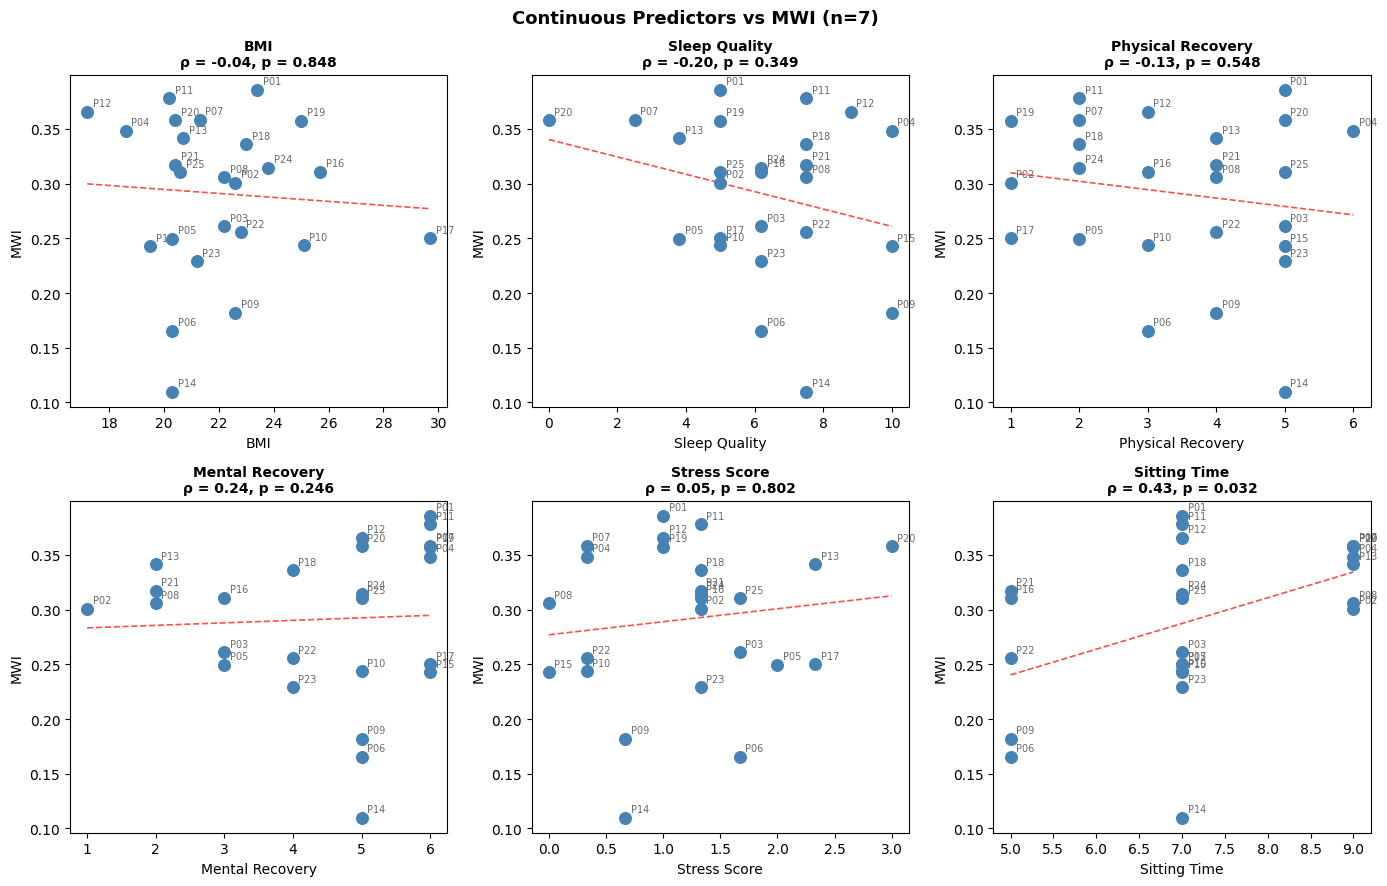

In [90]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for ax, (col, label) in zip(axes, CONT_PREDICTORS):
    x = pd.to_numeric(df[col], errors='coerce')
    y = df['mwi']
    mask = x.notna()
    xv, yv = x[mask].values, y[mask].values

    ax.scatter(xv, yv, color='steelblue', s=70, zorder=5)
    for i, idx in enumerate(x[mask].index):
        ax.annotate(df.loc[idx, 'name'].strip().split()[-1],
                    (xv[i], yv[i]), fontsize=7, xytext=(4, 4), textcoords='offset points', color='dimgrey')

    if len(xv) > 2:
        m, b = np.polyfit(xv, yv, 1)
        xline = np.linspace(xv.min(), xv.max(), 50)
        ax.plot(xline, m * xline + b, 'r--', linewidth=1.2, alpha=0.7)

    r, p = stats.spearmanr(xv, yv)
    ax.set_title(f'{label}\nρ = {r:.2f}, p = {p:.3f}', fontsize=10, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('MWI')

plt.suptitle('Continuous Predictors vs MWI (n=7)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Categorical predictors

Mann-Whitney U is used for binary variables; Kruskal-Wallis H for variables with more than two categories. Both are non-parametric rank-based tests appropriate for small n. Given the tiny sample, effect sizes and group medians are the primary focus — p-values are indicative only.

In [101]:
CAT_PREDICTORS = [
    ('training_category',  'Training Category'),
    ('gender',             'Gender'),
    ('hypermobility',      'Hypermobility'),
    ('injury_presence',    'Injury Presence'),
    ('chronic_pain',       'Chronic Pain'),
    ('age_group',          'Age Group'),
    ('early_life_training','Early-Life Training'),
    ('end_range_control',  'End-Range Control'),
    ('weekly_volume',      'Weekly Volume'),
    ('sleep_duration',     'Sleep Duration'),
]

cat_rows = []

for col, label in CAT_PREDICTORS:
    sub = df[[col, 'mwi']].dropna()
    groups = [g['mwi'].values for _, g in sub.groupby(col) if len(g) >= 2]

    if len(groups) >= 2:
        if sub[col].nunique() == 2:
            stat, p = stats.mannwhitneyu(*groups[:2], alternative='two-sided')
            n1, n2 = len(groups[0]), len(groups[1])
            effect = (2 * stat) / (n1 * n2) - 1
            test, effect_name = 'Mann-Whitney U', 'rank-biserial r'
        else:
            stat, p = stats.kruskal(*groups)
            n_total, k = len(sub), sub[col].nunique()
            effect = (stat - k + 1) / (n_total - k) if n_total > k else np.nan
            test, effect_name = 'Kruskal-Wallis H', 'epsilon_sq'
        cat_rows.append({'Variable': label, 'n': len(sub), 'Groups': sub[col].nunique(),
                         'Test': test, 'stat': round(stat, 3), 'p-value': round(p, 3),
                         'effect_type': effect_name, 'effect_size': round(effect, 3)})
    else:
        cat_rows.append({'Variable': label, 'n': len(sub), 'Groups': sub[col].nunique(),
                         'Test': 'n/a', 'stat': np.nan, 'p-value': np.nan,
                         'effect_type': 'n/a', 'effect_size': np.nan})

cat_results = pd.DataFrame(cat_rows)
cat_results


,Variable,n,Groups,Test,stat,p-value,effect_type,effect_size
0,Training Category,25,4,Kruskal-Wallis H,3.639,0.303,epsilon_sq,0.030
1,Gender,25,2,Mann-Whitney U,57.000,0.549,rank-biserial r,-0.162
2,Hypermobility,25,2,Mann-Whitney U,77.000,0.934,rank-biserial r,0.027
3,Injury Presence,25,2,Mann-Whitney U,59.000,0.628,rank-biserial r,-0.132
4,Chronic Pain,25,3,Kruskal-Wallis H,0.798,0.671,epsilon_sq,-0.055
5,Age Group,25,4,Kruskal-Wallis H,0.095,0.954,epsilon_sq,-0.138
6,Early-Life Training,25,5,Kruskal-Wallis H,2.089,0.554,epsilon_sq,-0.096
7,End-Range Control,25,4,Kruskal-Wallis H,4.264,0.234,epsilon_sq,0.060
8,Weekly Volume,25,4,Kruskal-Wallis H,2.241,0.326,epsilon_sq,-0.036
9,Sleep Duration,25,3,Kruskal-Wallis H,3.202,0.074,epsilon_sq,0.055


In [ ]:
from scipy.stats import kruskal

# Get median MWI per sleep duration group
print(df.groupby('sleep_duration')['mwi'].median().sort_index())

# Check group sizes
print(df.groupby('sleep_duration')['mwi'].count())

sleep_duration
6–8 hours            0.305743
Less than 4 hours    0.250178
More than 8 hours    0.365681
Name: mwi, dtype: float64
sleep_duration
6–8 hours            21
Less than 4 hours     1
More than 8 hours     3
Name: mwi, dtype: int64


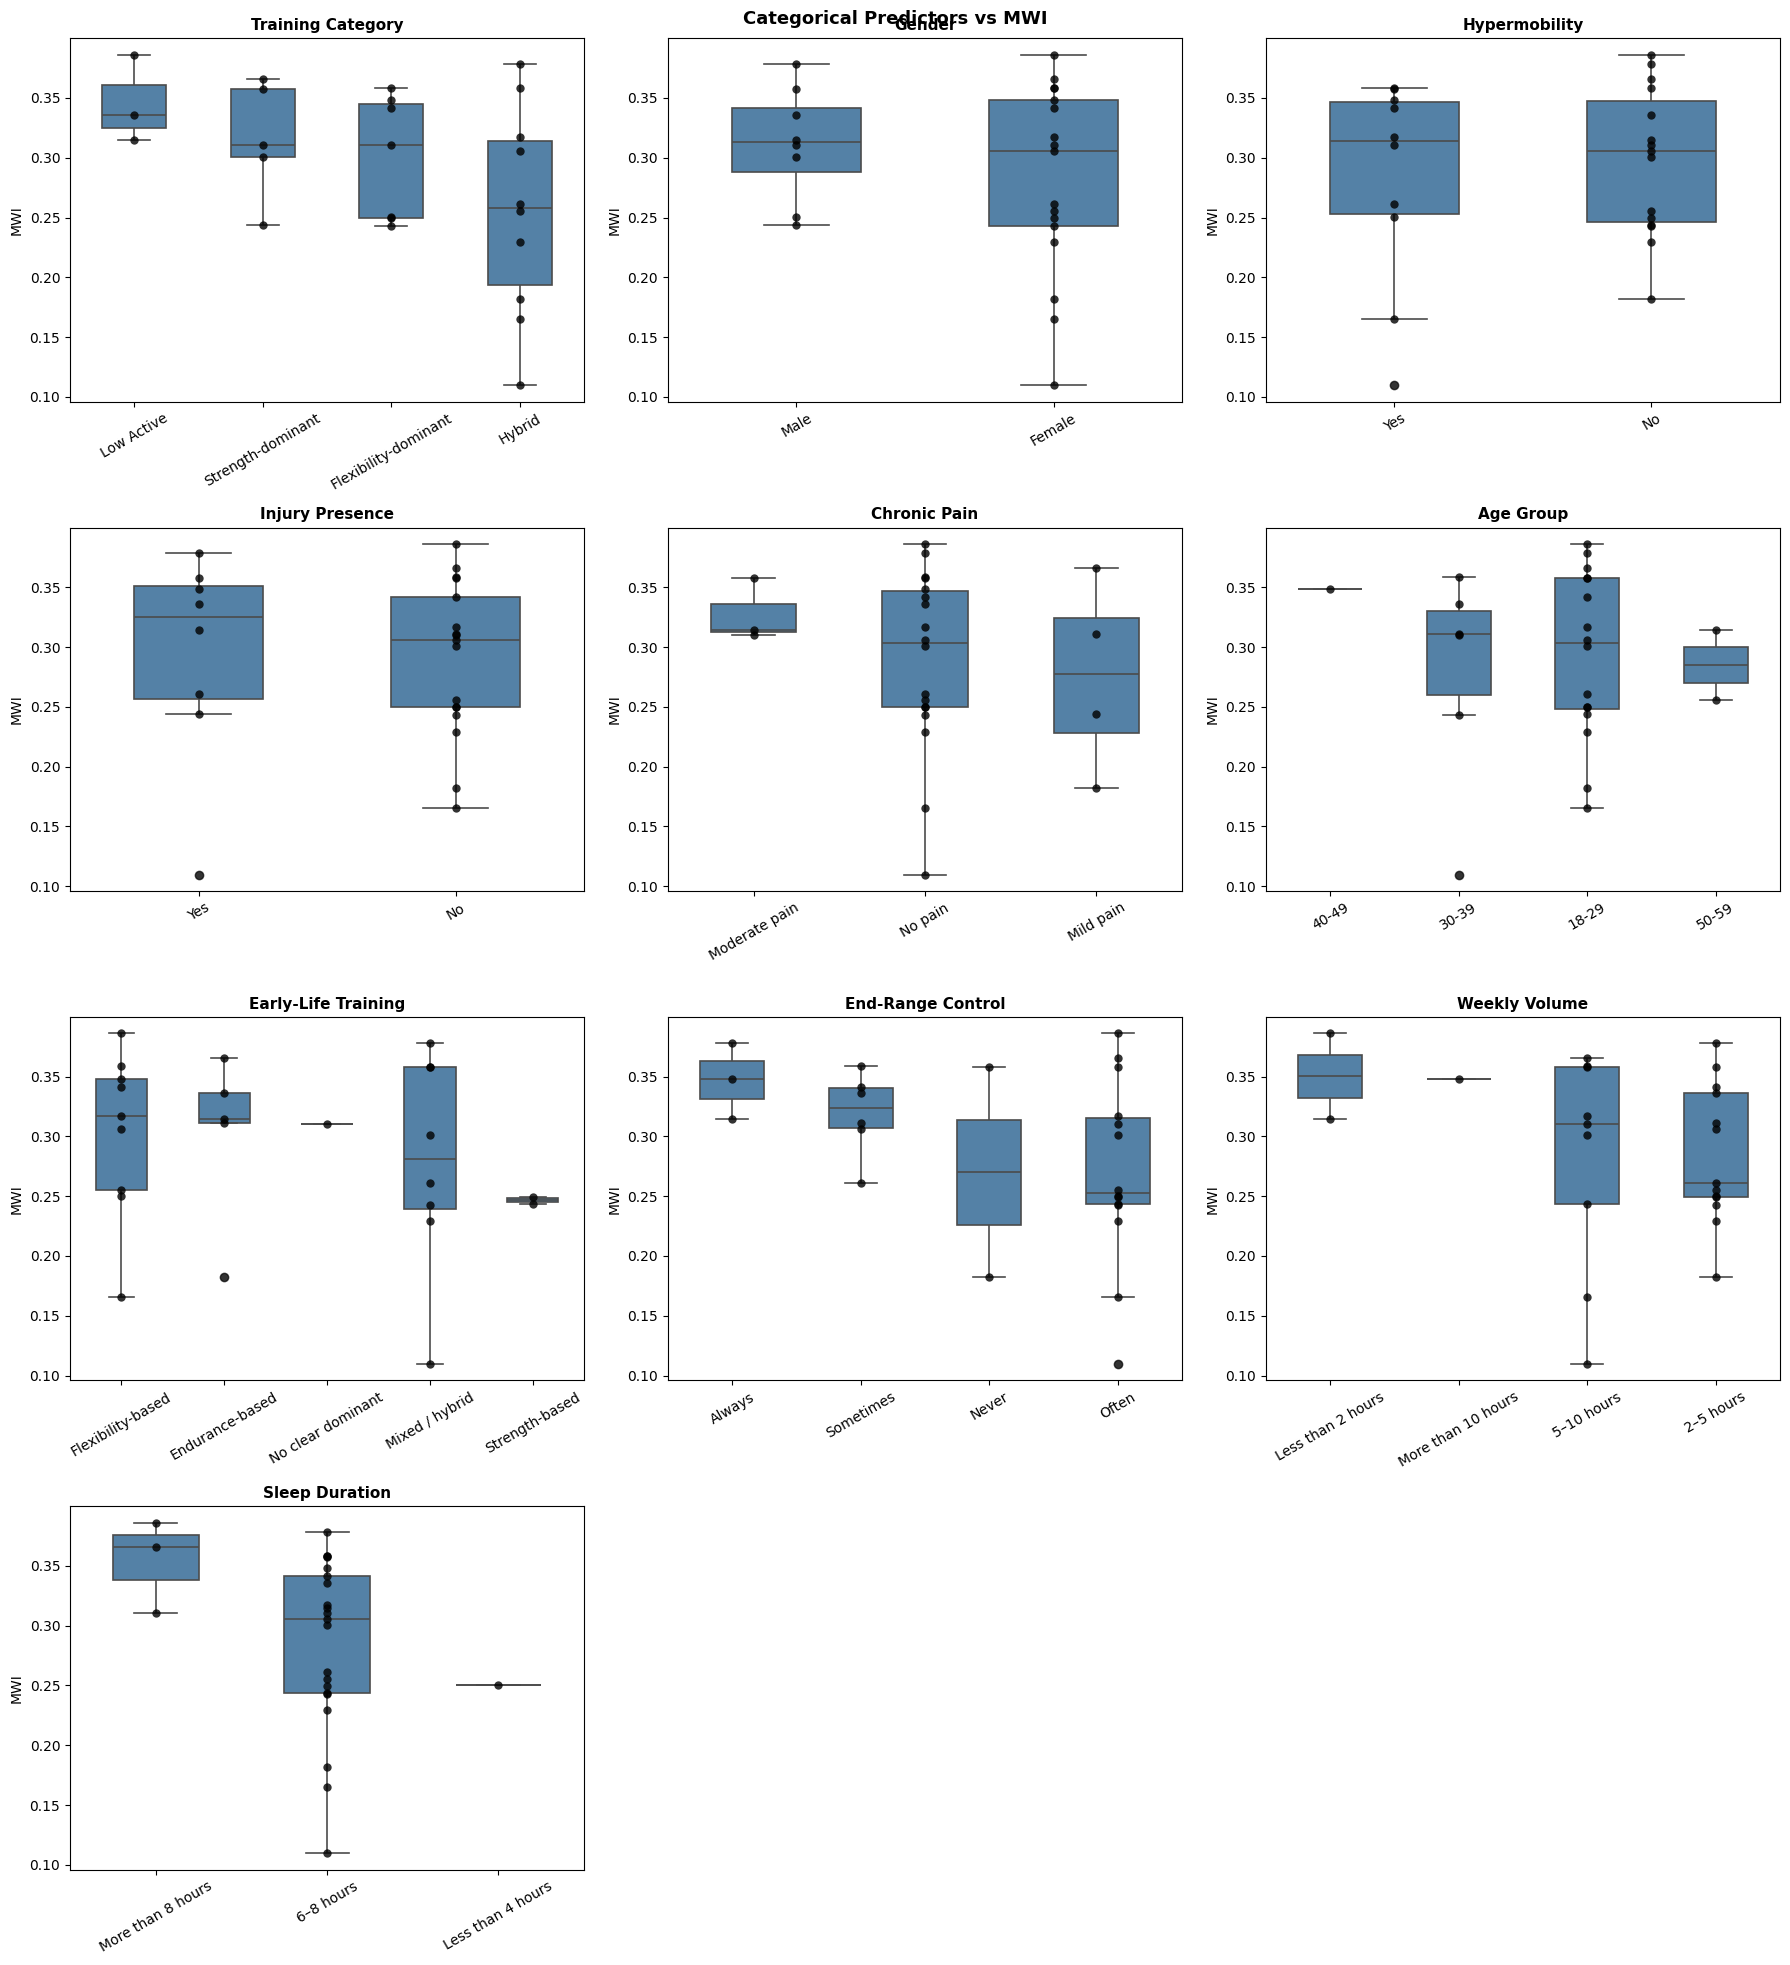

In [92]:
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, (col, label) in enumerate(CAT_PREDICTORS):
    ax = axes[i]
    sub = df[[col, 'mwi']].dropna()
    if sub[col].nunique() < 2:
        ax.set_visible(False)
        continue
    order = sub.groupby(col)['mwi'].median().sort_values(ascending=False).index.tolist()
    sns.boxplot(data=sub, x=col, y='mwi', order=order, ax=ax,
                color='steelblue', linewidth=1.2, width=0.5)
    sns.stripplot(data=sub, x=col, y='mwi', order=order, ax=ax,
                  color='black', size=6, jitter=False, alpha=0.8, zorder=5)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('MWI')
    ax.tick_params(axis='x', rotation=30)

for j in range(len(CAT_PREDICTORS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Predictors vs MWI', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Summary

In [ ]:
print('=' * 60)
print('BIVARIATE SCREENING SUMMARY — H1: Predictors of MWI')
print(f'Sample: n={len(df)} participants with MWI scores')
print('=' * 60)

cont_sorted = cont_results.sort_values('Spearman ρ', key=abs, ascending=False)
print('\nContinuous predictors (sorted by |ρ|, descending):')
print(cont_sorted.to_string(index=False))

cat_sorted = cat_results.sort_values('p-value', ascending=True)
print('\nCategorical predictors (sorted by p-value, ascending):')
print(cat_sorted[['Variable', 'n', 'Groups', 'Test', 'p-value']].to_string(index=False))

# Top 5 predictors 
all_candidates = []
for _, row in cont_sorted.iterrows():
    all_candidates.append({'Variable': row['Variable'], 'p-value': row['p-value']})
for _, row in cat_sorted.iterrows():
    all_candidates.append({'Variable': row['Variable'], 'p-value': row['p-value']})

top5 = sorted(all_candidates, key=lambda x: x['p-value'])[:5]
print('\nTop 5 predictors (ranked by p-value):')
for i, c in enumerate(top5, 1):
    print(f"  {i}. {c['Variable']:25s}  p = {c['p-value']:.3f}")

BIVARIATE SCREENING SUMMARY — H1: Predictors of MWI
Sample: n=25 participants with MWI scores

Continuous predictors (sorted by |ρ|, descending):
         Variable  n  Spearman ρ  p-value
     Sitting Time 25       0.430    0.032
  Mental Recovery 25       0.241    0.246
    Sleep Quality 25      -0.196    0.349
  Sedentary Score 25       0.134    0.524
Physical Recovery 25      -0.126    0.548
     Stress Score 25       0.053    0.802
              BMI 25      -0.040    0.848

Categorical predictors (sorted by p-value, ascending):
           Variable  n  Groups             Test  p-value
     Sleep Duration 25       3 Kruskal-Wallis H    0.074
  End-Range Control 25       4 Kruskal-Wallis H    0.234
  Training Category 25       4 Kruskal-Wallis H    0.303
      Weekly Volume 25       4 Kruskal-Wallis H    0.326
             Gender 25       2   Mann-Whitney U    0.549
Early-Life Training 25       5 Kruskal-Wallis H    0.554
    Injury Presence 25       2   Mann-Whitney U    0.628
      

## Regression Analysis — Beta (primary) & OLS (benchmark)

Both models were fitted using the same predictors: `sitting_time` (continuous) and `training_category` (categorical, ref = Low Active).  
Beta regression is the primary model given the bounded (0, 1) nature of MWI; OLS serves as a robustness benchmark.  
Models are assessed on direction and significance of effects (α = 0.05), not coefficient magnitude, with fitted means expected to be similar.

| Section | Beta | OLS |
|---|---|---|
| Global fit | Likelihood Ratio Test (χ²) | Omnibus F-test |
| Within-model fit | AIC · BIC · Pseudo-R² | AIC · BIC · Adj. R² |

In [108]:
import statsmodels.api as sm

CONT_REG   = ['sitting_time']
CAT_REG    = 'training_category'
CAT_ORDER  = ['Low Active', 'Flexibility-dominant', 'Strength-dominant', 'Hybrid']
DUMMY_LABELS = {
    'Flexibility-dominant': 'Flexibility-dominant vs Low Active',
    'Strength-dominant':    'Strength-dominant vs Low Active',
    'Hybrid':               'Hybrid vs Low Active',
}
feature_cols = CONT_REG + list(DUMMY_LABELS.values())

reg_df = df[['name', 'mwi'] + CONT_REG + [CAT_REG]].dropna().copy().reset_index(drop=True)
reg_df[CAT_REG] = pd.Categorical(reg_df[CAT_REG], categories=CAT_ORDER, ordered=False)
for cat, label in DUMMY_LABELS.items():
    reg_df[label] = (reg_df[CAT_REG] == cat).astype(int)

X_reg = sm.add_constant(reg_df[feature_cols].astype(float))
y_reg = reg_df['mwi'].astype(float)

print(f'OLS  |  n = {len(reg_df)}  |  ref = Low Active')
print(f'Predictors: {feature_cols}\n')

#  Fit 
ols_model = sm.OLS(y_reg, X_reg).fit()
print(ols_model.summary())


OLS  |  n = 25  |  ref = Low Active
Predictors: ['sitting_time', 'Flexibility-dominant vs Low Active', 'Strength-dominant vs Low Active', 'Hybrid vs Low Active']

                            OLS Regression Results                            
Dep. Variable:                    mwi   R-squared:                       0.361
Model:                            OLS   Adj. R-squared:                  0.233
Method:                 Least Squares   F-statistic:                     2.825
Date:                Fri, 10 Apr 2026   Prob (F-statistic):             0.0523
Time:                        11:08:07   Log-Likelihood:                 36.844
No. Observations:                  25   AIC:                            -63.69
Df Residuals:                      20   BIC:                            -57.59
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                         coef  

---

## Beta Regression (primary model)

MWI is a proportion bounded in (0, 1), which violates OLS assumptions of unbounded, normally distributed errors.  
Beta regression uses a **logit link** and Beta-distributed errors, naturally respecting the (0, 1) support.  
Same predictors as OLS; ref = Low Active.

In [ ]:
from statsmodels.othermod.betareg import BetaModel
from scipy.stats import chi2 as chi2_dist
from scipy.special import logit as sp_logit

#  Data prep (same predictors as OLS) 
beta_df = df[['name', 'mwi'] + CONT_REG + [CAT_REG]].dropna().copy().reset_index(drop=True)
epsilon = 1e-6
beta_df['mwi'] = beta_df['mwi'].clip(epsilon, 1 - epsilon)
beta_df[CAT_REG] = pd.Categorical(beta_df[CAT_REG], categories=CAT_ORDER, ordered=False)
for cat, label in DUMMY_LABELS.items():
    beta_df[label] = (beta_df[CAT_REG] == cat).astype(int)

X_beta = sm.add_constant(beta_df[feature_cols].astype(float))
y_beta = beta_df['mwi'].astype(float)

print(f'Beta  |  n = {len(beta_df)}  |  ref = Low Active')
print(f'MWI range: [{y_beta.min():.4f}, {y_beta.max():.4f}]\n')

_ols_init  = sm.OLS(sp_logit(y_beta.values), X_beta).fit()
_mu_hat    = 1.0 / (1.0 + np.exp(-_ols_init.fittedvalues))
_phi_start = max(np.mean(_mu_hat * (1 - _mu_hat)) / float(np.var(y_beta)) - 1, 1.0)
_start     = np.append(_ols_init.params, np.log(_phi_start))

#  Fit 
beta_model = BetaModel(y_beta, X_beta)
beta_res   = beta_model.fit(start_params=_start, disp=False, method='bfgs')

null_model = BetaModel(y_beta, np.ones((len(y_beta), 1)))
_null_start = np.array([sp_logit(float(y_beta.mean())), np.log(_phi_start)])
null_res   = null_model.fit(start_params=_null_start, disp=False, method='bfgs')

# Summary 
_summary_lines = [l for l in str(beta_res.summary()).splitlines()
                  if 'precision' not in l.lower()]
print('\n'.join(_summary_lines))

# Precision φ 
log_phi     = beta_res.params[-1]
phi_natural = np.exp(log_phi)
print(f'\nPrecision  φ = {phi_natural:.2f}  (natural scale)')

#  Global fit: Likelihood Ratio Test 
lrt_stat = 2 * (beta_res.llf - null_res.llf)
lrt_df   = len(feature_cols)
lrt_p    = chi2_dist.sf(lrt_stat, lrt_df)
sig      = '  *' if lrt_p < 0.05 else ''
print('\n── Global fit ───────────────────────────────────────────────────────────────')
print(f'  Null  logLik = {null_res.llf:.3f}  (df = 2)')
print(f'  Full  logLik = {beta_res.llf:.3f}  (df = {lrt_df + 2})')
print(f'  χ²({lrt_df}) = {lrt_stat:.3f},  p = {lrt_p:.4f}{sig}')

# ── Within-model fit ──────────────────────────────────────────────────────────
lin_pred  = X_beta.values @ beta_res.params[:len(feature_cols) + 1]
pseudo_r2 = float(np.corrcoef(sp_logit(y_beta.values), lin_pred)[0, 1] ** 2)
print('\n── Within-model fit ─────────────────────────────────────────────────────────')
print(f'  Pseudo-R²  = {pseudo_r2:.3f}  (Ferrari & Cribari-Neto)')
print(f'  AIC        = {beta_res.aic:.3f}')
print(f'  BIC        = {beta_res.bic:.3f}')
print(f'  logLik     = {beta_res.llf:.3f}')

#  Coefficients 
ci_b = beta_res.conf_int()
coef_beta_df = pd.DataFrame({
    'β (logit)':   beta_res.params[1:len(feature_cols)+1],
    'Std Err':     beta_res.bse[1:len(feature_cols)+1],
    'z':           beta_res.tvalues[1:len(feature_cols)+1],
    'p-value':     beta_res.pvalues[1:len(feature_cols)+1],
    'exp(β)':      np.exp(beta_res.params[1:len(feature_cols)+1]),
    '[0.025':      ci_b.iloc[1:len(feature_cols)+1, 0],
    '0.975]':      ci_b.iloc[1:len(feature_cols)+1, 1],
}, index=feature_cols).round(4)


Beta  |  n = 25  |  ref = Low Active
MWI range: [0.1099, 0.3860]

                              BetaModel Results                               
Dep. Variable:                    mwi   Log-Likelihood:                 35.457
Model:                      BetaModel   AIC:                            -58.91
Method:            Maximum Likelihood   BIC:                            -51.60
Date:                Tue, 07 Apr 2026                                         
Time:                        21:48:42                                         
No. Observations:                  25                                         
Df Residuals:                      19                                         
Df Model:                           4                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
const            

/var/folders/s_/c14ll07j3fvb_99plyhxh1m40000gn/T/ipykernel_32789/3019415351.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  log_phi     = beta_res.params[-1]


In [ ]:

#  Model comparison: Beta vs OLS 
comp = pd.DataFrame({
    'Beta': [
        f'χ²({lrt_df}) = {lrt_stat:.3f}',
        f'{lrt_p:.4f}{"  *" if lrt_p < 0.05 else ""}',
        f'{pseudo_r2:.3f}',
        '—',
        f'{beta_res.aic:.3f}',
        f'{beta_res.bic:.3f}',
        f'{beta_res.llf:.3f}',
    ],
    'OLS': [
        f'F({ols_model.df_model:.0f}, {ols_model.df_resid:.0f}) = {ols_model.fvalue:.3f}',
        f'{ols_model.f_pvalue:.4f}{"  *" if ols_model.f_pvalue < 0.05 else ""}',
        f'{ols_model.rsquared:.3f}',
        f'{ols_model.rsquared_adj:.3f}',
        f'{ols_model.aic:.3f}',
        f'{ols_model.bic:.3f}',
        f'{ols_model.llf:.3f}',
    ],
}, index=['Global test', 'Global p', 'R² / Pseudo-R²', 'Adj. R²', 'AIC', 'BIC', 'logLik'])
comp.index.name = 'Metric'

print('── Model comparison ─────────────────────────────────────────────────────────')
print(comp.to_string())

#  Fitted means at sitting_time = 7 per category 
print('\n── Fitted means at sitting_time = 7 ─────────────────────────────────────────')
print(f'  {"Category":<30}  {"Beta":>8}  {"OLS":>8}')
print('  ' + '─' * 50)
for cat in CAT_ORDER:
    dummies  = [1.0 if k == cat else 0.0 for k in DUMMY_LABELS]
    x_row    = np.array([1.0, 7.0] + dummies)
    mu_beta  = float(1.0 / (1.0 + np.exp(-(beta_res.params[:len(feature_cols)+1] @ x_row))))
    mu_ols   = float(ols_model.params @ x_row)
    print(f'  {cat:<30}  {mu_beta:>8.4f}  {mu_ols:>8.4f}')

fitted_beta = 1.0 / (1.0 + np.exp(-lin_pred))
fitted_ols  = ols_model.fittedvalues.values
cor_val     = float(np.corrcoef(fitted_beta, fitted_ols)[0, 1])
print(f'\nCor(fitted Beta, fitted OLS) = {cor_val:.4f}')


── Model comparison ─────────────────────────────────────────────────────────
                          Beta               OLS
Metric                                          
Global test     χ²(4) = 11.061  F(4, 20) = 2.825
Global p             0.0259  *            0.0523
R² / Pseudo-R²           0.335             0.361
Adj. R²                      —             0.233
AIC                    -58.915           -63.687
BIC                    -51.602           -57.593
logLik                  35.457            36.844

── Fitted means at sitting_time = 7 ─────────────────────────────────────────
  Category                            Beta       OLS
  ──────────────────────────────────────────────────
  Low Active                        0.3476    0.3455
  Flexibility-dominant              0.2832    0.2816
  Strength-dominant                 0.3065    0.3072
  Hybrid                            0.2587    0.2649

Cor(fitted Beta, fitted OLS) = 0.9976


/var/folders/s_/c14ll07j3fvb_99plyhxh1m40000gn/T/ipykernel_32789/2347213142.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  phi_val = np.exp(beta_res.params[-1])          # precision φ on natural scale


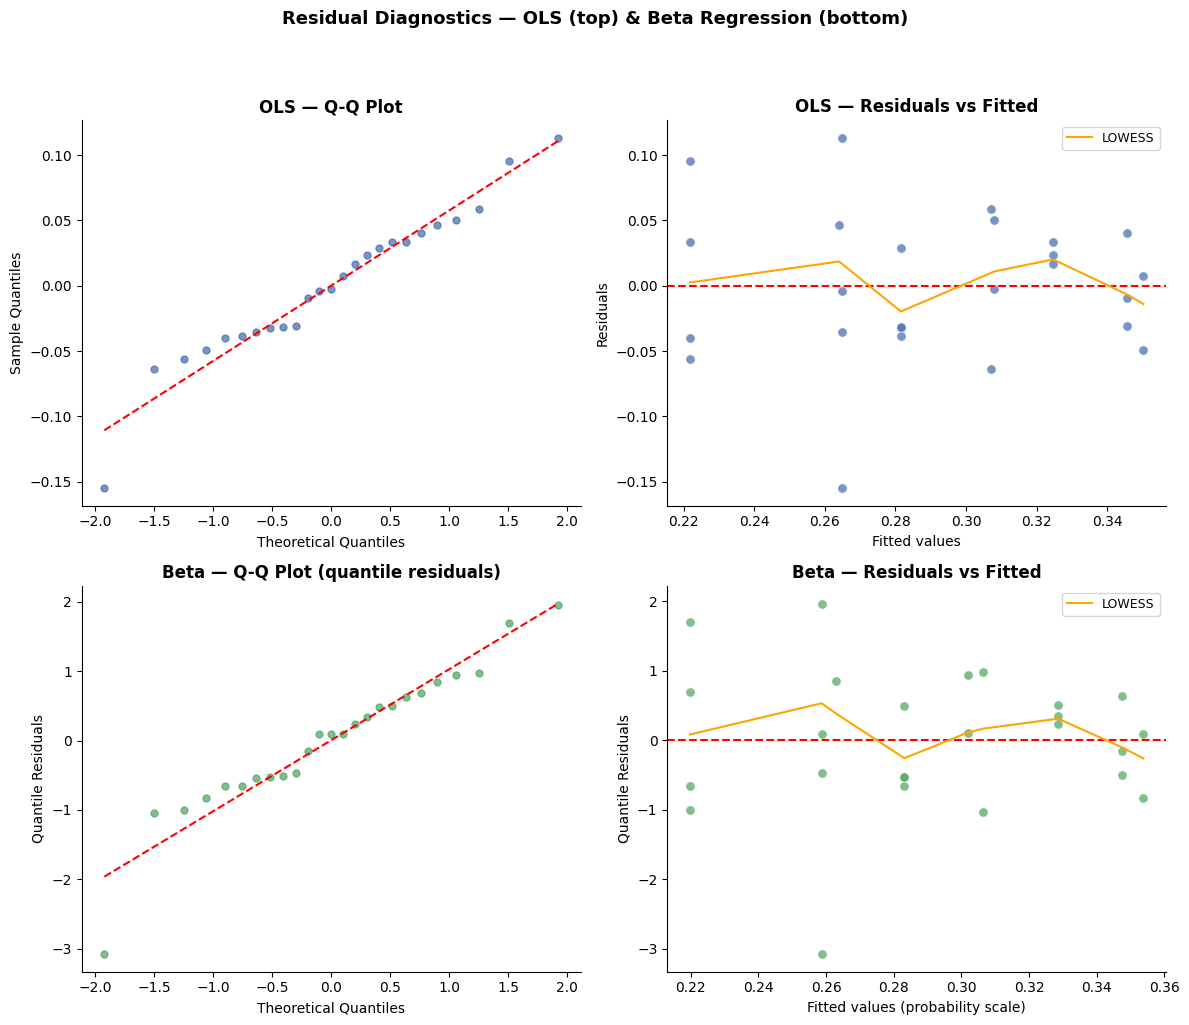

In [ ]:
#  Residual diagnostic plots — OLS & Beta regression 
from scipy import stats as scipy_stats
from scipy.stats import beta as beta_dist, norm as norm_dist

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

#  OLS Q-Q 
ax = axes[0, 0]
(osm, osr), (slope, intercept, _) = scipy_stats.probplot(ols_model.resid, dist='norm')
ax.plot(osm, osr, 'o', color='#4c72b0', alpha=0.75, markersize=5)
ax.plot(osm, slope * np.array(osm) + intercept, 'r--', lw=1.5)
ax.set_title('OLS — Q-Q Plot', fontweight='bold')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')
ax.spines[['top', 'right']].set_visible(False)

#  OLS Residuals vs Fitted 
ax = axes[0, 1]
ax.scatter(ols_model.fittedvalues, ols_model.resid,
           color='#4c72b0', alpha=0.75, s=45, edgecolors='white', lw=0.5)
ax.axhline(0, color='red', lw=1.5, ls='--')
lo = sm.nonparametric.lowess(ols_model.resid, ols_model.fittedvalues, frac=0.5)
ax.plot(lo[:, 0], lo[:, 1], color='orange', lw=1.5, label='LOWESS')
ax.set_title('OLS — Residuals vs Fitted', fontweight='bold')
ax.set_xlabel('Fitted values')
ax.set_ylabel('Residuals')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

#  Beta: randomized quantile residuals
phi_val = np.exp(beta_res.params[-1])          # precision φ on natural scale
a_par   = fitted_beta * phi_val
b_par   = (1 - fitted_beta) * phi_val
u       = beta_dist.cdf(y_beta.values, a_par, b_par)
u       = np.clip(u, 1e-10, 1 - 1e-10)       
q_resid = norm_dist.ppf(u)                     

# Beta Q-Q 
ax = axes[1, 0]
(osm, osr), (slope, intercept, _) = scipy_stats.probplot(q_resid, dist='norm')
ax.plot(osm, osr, 'o', color='#55a868', alpha=0.75, markersize=5)
ax.plot(osm, slope * np.array(osm) + intercept, 'r--', lw=1.5)
ax.set_title('Beta — Q-Q Plot (quantile residuals)', fontweight='bold')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Quantile Residuals')
ax.spines[['top', 'right']].set_visible(False)

#  Beta Residuals vs Fitted 
ax = axes[1, 1]
ax.scatter(fitted_beta, q_resid,
           color='#55a868', alpha=0.75, s=45, edgecolors='white', lw=0.5)
ax.axhline(0, color='red', lw=1.5, ls='--')
lo = sm.nonparametric.lowess(q_resid, fitted_beta, frac=0.5)
ax.plot(lo[:, 0], lo[:, 1], color='orange', lw=1.5, label='LOWESS')
ax.set_title('Beta — Residuals vs Fitted', fontweight='bold')
ax.set_xlabel('Fitted values (probability scale)')
ax.set_ylabel('Quantile Residuals')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Residual Diagnostics — OLS (top) & Beta Regression (bottom)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [ ]:
#  Bootstrap 95% CI for sitting_time β 
np.random.seed(42)
B       = 199
n_obs   = len(beta_df)
sit_idx = feature_cols.index('sitting_time') + 1   

boot_coefs = []
for _ in range(B):
    idx  = np.random.choice(n_obs, size=n_obs, replace=True)
    bd   = beta_df.iloc[idx].reset_index(drop=True)
    y_b  = bd['mwi'].values.astype(float)
    X_b  = sm.add_constant(bd[feature_cols].astype(float))
    try:
        m = BetaModel(y_b, X_b).fit(disp=False, maxiter=200)
        boot_coefs.append(float(m.params[sit_idx]))
    except Exception:
        boot_coefs.append(np.nan)

boot_arr          = np.array(boot_coefs)
ci_lo, ci_hi      = np.nanpercentile(boot_arr, [2.5, 97.5])
n_ok              = int(np.sum(~np.isnan(boot_arr)))
point_est         = float(beta_res.params[sit_idx])

print(f'Bootstrap 95% CI for sitting_time (logit scale)  B = {B}:')
print(f'  2.5% : {ci_lo:.4f}')
print(f'  97.5%: {ci_hi:.4f}')
print(f'Point estimate: {point_est:.4f}')
print(f'Successful draws: {n_ok} / {B}')


/var/folders/s_/c14ll07j3fvb_99plyhxh1m40000gn/T/ipykernel_32789/631107724.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  boot_coefs.append(float(m.params[sit_idx]))
/var/folders/s_/c14ll07j3fvb_99plyhxh1m40000gn/T/ipykernel_32789/631107724.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  boot_coefs.append(float(m.params[sit_idx]))
/var/folders/s_/c14ll07j3fvb_99plyhxh1m40000gn/T/ipykernel_32789/631107724.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value

Bootstrap 95% CI for sitting_time (logit scale)  B = 199:
  2.5% : 0.0228
  97.5%: 0.1951
Point estimate: 0.1072
Successful draws: 199 / 199


/var/folders/s_/c14ll07j3fvb_99plyhxh1m40000gn/T/ipykernel_32789/631107724.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  boot_coefs.append(float(m.params[sit_idx]))
/var/folders/s_/c14ll07j3fvb_99plyhxh1m40000gn/T/ipykernel_32789/631107724.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  boot_coefs.append(float(m.params[sit_idx]))
/var/folders/s_/c14ll07j3fvb_99plyhxh1m40000gn/T/ipykernel_32789/631107724.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value

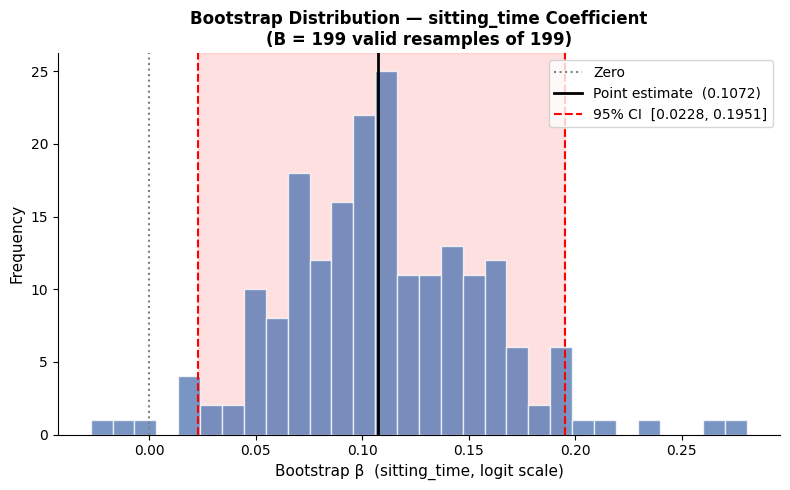

The 95% bootstrap CI excludes zero  (0.0228, 0.1951).


In [ ]:
#  Bootstrap distribution — sitting_time coefficient 
clean_boots = boot_arr[~np.isnan(boot_arr)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(clean_boots, bins=30, color='#4c72b0', alpha=0.75, edgecolor='white', zorder=2)

# 95% CI shaded band
ax.axvspan(ci_lo, ci_hi, alpha=0.12, color='red', zorder=1, label='_nolegend_')

# Reference lines
ax.axvline(0,         color='grey',  lw=1.5, ls=':',  label='Zero',                    zorder=3)
ax.axvline(point_est, color='black', lw=2,   ls='-',
           label=f'Point estimate  ({point_est:.4f})',                                  zorder=4)
ax.axvline(ci_lo,     color='red',   lw=1.5, ls='--',
           label=f'95% CI  [{ci_lo:.4f}, {ci_hi:.4f}]',                                zorder=3)
ax.axvline(ci_hi,     color='red',   lw=1.5, ls='--',                                  zorder=3)

ax.set_xlabel('Bootstrap β  (sitting_time, logit scale)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title(
    f'Bootstrap Distribution — sitting_time Coefficient\n'
    f'(B = {len(clean_boots)} valid resamples of {B})',
    fontweight='bold'
)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

excl = 'excludes' if ci_lo > 0 or ci_hi < 0 else 'includes'
print(f'The 95% bootstrap CI {excl} zero  ({ci_lo:.4f}, {ci_hi:.4f}).')